# Gast-Solla-Kennedy model: resting state on a full connectome

This demo simulates the **adaptive-Izhikevich mean-field model** of
Gast, Solla & Kennedy (2024, *PNAS* 121(22) e2311885121,
[doi:10.1073/pnas.2311885121](https://doi.org/10.1073/pnas.2311885121))
on a whole-brain structural connectome, in its **resting / quiescent regime**.

The model is a four-dimensional firing-rate reduction of a population of
all-to-all coupled adaptive (Izhikevich) neurons with a Lorentzian
distribution of spike thresholds. Its state variables are

| symbol | meaning |
|---|---|
| `r` | mean firing rate of the population (kHz) |
| `v` | mean membrane potential (mV) |
| `u` | mean recovery / spike-frequency-adaptation current (pA) |
| `s` | synaptic gating variable, driven by `r` |

The TVB implementation lives in `tvb.simulator.models.GastSollaKennedy`
(default parameters = regular-spiking RS column of Table 1 of the paper).
A companion notebook, `reproduce_figure_Gast_2024_PNAS.ipynb`, reproduces
the bifurcation / firing-rate panels of the paper at the single-population
level; this notebook instead places the model on the **76-region human
connectome** and looks at the low-activity resting state.

**Regime.** We start the population at its quiescent fixed point
(`r = 0`, `v = -60 mV`) and drive it with a small homogeneous external
current (`I = 30 pA`). This keeps the mean firing rate at, or extremely
close to, zero -- the population is *at rest* rather than tonically firing.
A short second run, started from a perturbed high-rate state, shows that
this resting state is a stable attractor.

### Why this model, and why a "resting state"?

In the paper, the width of the spike-threshold distribution $\Delta$ decides
whether an inhibitory population preserves or overwrites the bifurcation
structure of an excitatory population (mapped out in the companion notebook
`reproduce_figure_Gast_2024_PNAS.ipynb`). The **single excitatory population**
embedded in TVB keeps the interesting excitatory phenomenology on its own:
over a broad input range it is **bistable** - a quiescent (silently resting)
fixed point coexists with a tonically spiking one (panel A of the reproduced
Figure 2). That makes the quiescent corner of phase space a meaningful regime
to probe on a connectome: every region receives its neighbours' activity
through the structural coupling, and one can ask whether rest survives that
embedding and perturbations.

Three clarifications before starting:

* **"Resting state" here is a dynamical statement, not an empirical one.** It
  means the population sits at its quiescent fixed point (mean firing rate
  approximately 0). The simulation is deterministic, so it produces *silence*,
  not the fluctuating spontaneous activity measured with resting-state fMRI,
  and no comparison to empirical functional connectivity is attempted (see the
  limitations in the Summary).
* **Bistability is what makes the resting state interesting.** At the
  parameters used here ($\Delta=0.5$ mV, $I=30$ pA) the population lies inside
  the bistable fold region of the model's bifurcation diagram (companion
  notebook, panel A): rest is a genuine attractor, not the only available
  state. Section 5 probes that attractor with a perturbation.
* **This is not TVB's other "Gast" model family.** The models in
  `tvb.simulator.models.infinite_theta` (`GastSchmidtKnosche_SD` /
  `GastSchmidtKnosche_SF`, Gast, Schmidt & Knosche 2020) are Ott-Antonsen
  reductions of QIF/theta neurons (see `theta_neuron_models.ipynb`);
  `GastSollaKennedy` is the reduction of **adaptive Izhikevich** neurons
  (Gast, Solla & Kennedy 2024).

In [1]:
from tvb.simulator.lab import *
import matplotlib.pyplot as plt
import numpy

## 1. Structural connectivity and model

We use the default 76-region structural connectome shipped with TVB
(weights + conduction delays). Note that this checkout requires an explicit
`connectivity.Connectivity.from_file()` (the `load_default=True` form is not
valid here) followed by `configure()`.

### The model in brief

`GastSollaKennedy` is the exact firing-rate reduction of an infinite,
all-to-all coupled population of adaptive Izhikevich neurons with a Lorentzian
distribution of spike thresholds (Lorentzian ansatz in the spirit of
Montbrio-Pazo-Roxin, applied to the Izhikevich model; Gast, Schmidt & Knosche
2021; Gast, Solla & Kennedy 2024). The TVB defaults are the **regular-spiking
(RS, excitatory) parameter set** of Table 1 of the paper; the paper's
fast-spiking (FS, inhibitory) set of Table 2 is used in the two-population
experiments of the companion notebook, not here.

| parameter | default | meaning |
|---|---|---|
| `C` | 100 pF | membrane capacitance |
| `k` | 0.7 | scale of the quadratic membrane nonlinearity |
| `v_r` | -60 mV | resting membrane potential |
| `v_theta` ($\bar v_\theta$) | -40 mV | centre of the spike-threshold Lorentzian |
| `Delta` ($\Delta$) | 0.5 mV | **heterogeneity**: half-width of the threshold Lorentzian |
| `b` | -2 | recovery sensitivity to subthreshold voltage |
| `tau_u` | 33.33 ms | recovery time constant |
| `kappa` ($\kappa$) | 10 pA | spike-frequency adaptation strength |
| `tau_s` | 6 ms | synaptic time constant |
| `J` | 15 | synaptic weight driving the gating variable $s$ |
| `g` | 1.0 | synaptic conductance scale |
| `E_r` | 0 mV | synaptic reversal potential (excitatory, AMPA-like) |
| `I` | 0 pA (30 pA in this demo) | external homogeneous current |

Units follow the paper: `r` in kHz, `v` in mV, `u` in pA. How the macroscopic
dynamics depend on `I` and `Delta` - bistability vs oscillations - is the
subject of the companion notebook's bifurcation diagrams.

In [2]:
# Full 76-region human structural connectome (default weights and conduction delays)
conn = connectivity.Connectivity.from_file()
conn.configure()
print("Regions        :", conn.number_of_regions)
print("Max delay (mm) :", conn.tract_lengths.max())

# Adaptive-Izhikevich mean-field model (Gast, Solla & Kennedy 2024),
# regular-spiking (RS) parameter set (Table 1). A small external current of
# 30 pA places the population close to its quiescent (low-rate) fixed point.
model = models.GastSollaKennedy(I=numpy.array([30.0]))
print("Model          :", type(model).__name__)
print("State vars     :", model.state_variables)
print("Variables of interest (monitored):", model.variables_of_interest)

2026-09-23 14:47:55,723 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


Regions        : 76
Max delay (mm) : 153.48574
Model          : GastSollaKennedy
State vars     : ('r', 'v', 'u', 's')
Variables of interest (monitored): ('r',)


## 2. Helper: run the model on the full connectome

The longitudinal coupling is `coupling.Linear()` (the default), and the
model exposes its firing rate `r` to the coupling term. Integration is
deterministic (Heun, `dt = 0.01 ms`) and `r` is sampled every 1 ms.

`coupling.Linear()` (used with its default slope, approximately
$3.9\cdot10^{-3}$) maps the source regions' firing rate `r` onto a current
entering the target regions' membrane-potential equation: the model exposes
`r` as its coupling variable (`cr = 1`, `cv = 0`). While all regions sit at
`r` close to 0 this inter-regional input is negligible - the resting run below
effectively probes the *local* quiescent attractor under the connectome's
(silent) embedding.

In [3]:
def simulate(initial_rate, initial_v, initial_u, sim_length=1000.0):
    """Run the Gast-Solla-Kennedy mean field on the full connectome.

    The initial condition is homogeneous across regions and given by the
    per-region tuple ``(r, v, u, s)``: mean firing rate ``r`` (kHz),
    membrane potential ``v`` (mV), adaptation ``u`` (pA), gating ``s``.

    Returns the monitor time vector and the firing-rate array ``r(t)``
    with shape ``(time, regions)``.
    """
    x0 = numpy.array([initial_rate, initial_v, initial_u, 0.0])        # (r, v, u, s)
    ic = numpy.repeat(x0.reshape(4, 1, 1), conn.number_of_regions, axis=1)
    ic = ic.reshape((1, 4, conn.number_of_regions, 1))

    sim = simulator.Simulator(
        model=model,
        connectivity=conn,
        coupling=coupling.Linear(),
        integrator=integrators.HeunDeterministic(dt=0.01),
        monitors=(monitors.TemporalAverage(period=1.0),),
        initial_conditions=ic,
        simulation_length=sim_length,
    )
    sim.configure()

    (time, data), = sim.run()
    # data has shape (time, state_vars, regions, modes); state_vars = (r,)
    return time, data[:, 0, :, 0]

## 3. Resting-state simulation

Start every region at the quiescent fixed point: `r = 0`, `v = -60 mV`,
`u = 0`. With `I = 30 pA` the population stays at (or relaxes to) an
essentially zero firing-rate resting state.

At $I=30$ pA with $\Delta=0.5$ mV, the single-population bifurcation
diagram (companion notebook, panel A) places the population inside the
bistable fold region; the quiescent fixed point is stable but coexists with a
spiking attractor. The expectation for this run is therefore persistence at
(or fast relaxation to) `r` at or below $10^{-3}$ kHz - and nothing
oscillatory.

In [4]:
time, r = simulate(initial_rate=0.0, initial_v=-60.0, initial_u=0.0, sim_length=1000.0)
print("monitored r(t) shape :", r.shape)
print("mean rate over all regions/time : %.3e kHz (%.3e Hz)" % (r.mean(), 1e3 * r.mean()))
print("max  rate over all regions/time : %.3e kHz (%.3e Hz)" % (r.max(), 1e3 * r.max()))

2026-09-23 14:47:55,825 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


monitored r(t) shape : (1000, 76)
mean rate over all regions/time : 2.513e-04 kHz (2.513e-01 Hz)
max  rate over all regions/time : 2.609e-04 kHz (2.609e-01 Hz)


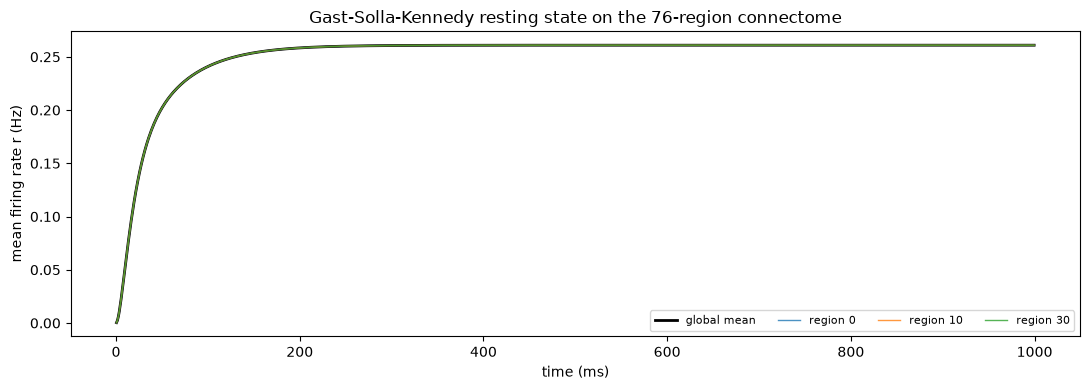

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(time, 1e3 * r.mean(axis=1), color="k", lw=2, label="global mean")
for i in (0, 10, 30):
    ax.plot(time, 1e3 * r[:, i], lw=1, alpha=0.8, label="region %d" % i)
ax.set_xlabel("time (ms)")
ax.set_ylabel("mean firing rate r (Hz)")
ax.set_title("Gast-Solla-Kennedy resting state on the 76-region connectome")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

The measured mean rate over all 76 regions and the full 1000 ms is about
$2.5\cdot10^{-4}$ kHz (about 0.25 Hz), and the maximum over regions and time is
of the same order: the population sits essentially at zero. This is the
quiescent fixed point of the model at $I=30$ pA - its small non-zero rate is a
property of that fixed point, not spiking activity. The per-region traces are
indistinguishable from the global mean on this scale: with all rates close to
zero the linear coupling contributes nothing, so the regions neither
desynchronise nor perturb one another.

## 4. Power spectrum of the resting-state activity

With the rate at a quiet fixed point the spectrum is essentially flat; this
is a useful sanity check that no spurious oscillation is present.

Because the trajectory is, after a short transient, a fixed point of a
deterministic system, the spectrum must be free of oscillatory peaks; any
broadband content above the numerical floor comes from the transient. A peak
would have flagged spurious limit-cycle dynamics (from discretisation or
coupling-induced instability) and would invalidate the quiescent reading of
section 3. The flatness is thus a sanity check, not a finding - add a
stochastic integrator if fluctuating, "resting-state-like" activity is the
goal.

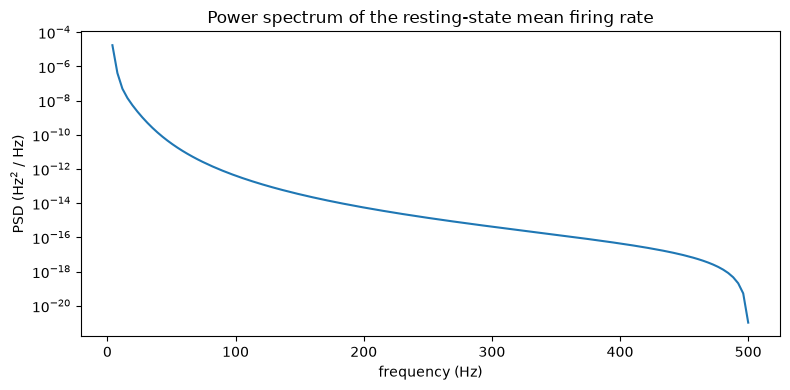

In [6]:
from scipy.signal import welch

fs = 1000.0  # TemporalAverage samples once per ms
freq, psd = welch(1e3 * r.mean(axis=1), fs=fs, nperseg=256)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(freq[1:], psd[1:])
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("PSD (Hz$^2$ / Hz)")
ax.set_title("Power spectrum of the resting-state mean firing rate")
plt.tight_layout()
plt.show()

## 5. Relaxation back to rest from a perturbed state

To show that the quiescent resting state is a *stable* attractor, we restart
the same connectome from a perturbed high-rate state (`r = 0.05 kHz`,
`v = -45 mV`) and watch the mean firing rate decay back towards the resting
level.

Because the resting state is only *locally* stable - it coexists with a
spiking attractor - a small perturbation must decay back, whereas a
sufficiently large one could in principle carry the population across the
separatrix into spiking (the pulse-driven switching shown in panels C/D of the
companion reproduction). The perturbation used here (`r = 0.05 kHz`,
`v = -45 mV`) turns out to be sub-threshold: the trace below shows the mean
rate decaying back towards the resting level of section 3 (dashed red line),
confirming local stability of the quiescent state in the connectome setting.

2026-09-23 14:48:32,651 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


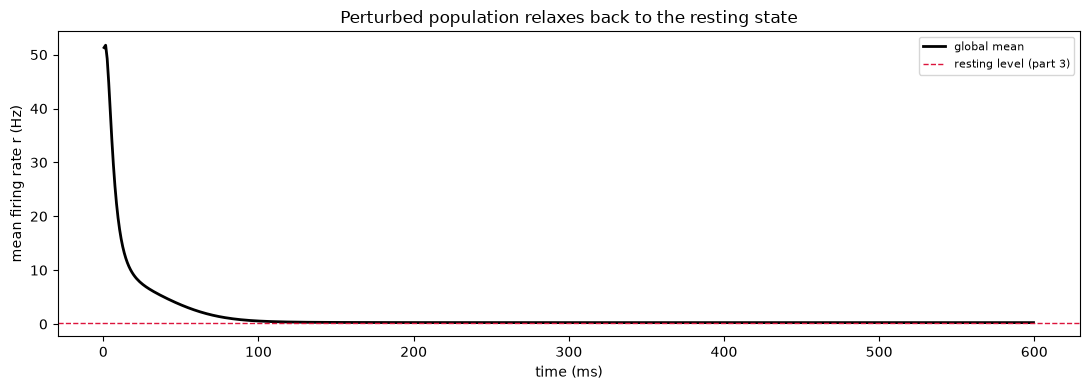

In [7]:
time_p, r_p = simulate(initial_rate=0.05, initial_v=-45.0, initial_u=5.0, sim_length=600.0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(time_p, 1e3 * r_p.mean(axis=1), color="k", lw=2, label="global mean")
ax.axhline(1e3 * r.mean(), color="crimson", ls="--", lw=1, label="resting level (part 3)")
ax.set_xlabel("time (ms)")
ax.set_ylabel("mean firing rate r (Hz)")
ax.set_title("Perturbed population relaxes back to the resting state")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary

* The `GastSollaKennedy` mean-field model (Gast, Solla & Kennedy 2024, PNAS)
  was simulated on the full 76-region connectome with linear coupling and a
  deterministic Heun integrator.
* Starting at the quiescent fixed point with a small external current
  (`I = 30 pA`), the population remains in a **resting / quiescent regime**
  (near-zero mean firing rate, flat power spectrum).
* A perturbed initial condition relaxes back to that resting level, i.e. the
  quiescent state is a stable attractor of the network dynamics.

### Limitations and next steps

* **No fluctuations.** With `HeunDeterministic` the resting state is a silent
  fixed point; realistic resting-state phenomenology (ongoing fluctuations,
  noise-driven switching between attractors) needs a stochastic integrator
  (e.g. `HeunStochastic`) or explicit noise on `I`.
* **No BOLD / empirical link.** Only the firing rate is monitored; connecting
  to fMRI resting-state functional connectivity would require a BOLD monitor
  and a comparison to empirical FC - out of scope here.
* **Default connectivity and coupling.** The unscaled 76-region weights and
  the default (weak) `coupling.Linear()` slope are used. At rest the coupling
  is silent anyway, but active-state simulations should revisit the global
  coupling strength and connectome scaling.
* **Mean-field assumptions.** The model is exact only for an infinite,
  all-to-all population with Lorentzian-distributed thresholds; each TVB
  region is treated as one such population, and only the RS (excitatory)
  parameter set is used - no local inhibition is modelled.

See the companion demo `reproduce_figure_Gast_2024_PNAS.ipynb` for the
bifurcation structure and firing-rate panels of the original paper.